# Эксперимент 1: EDA и Baseline-модель
**Цель:** провести первичный анализ данных и обучить базовую модель для оценки стоимости автомобилей.

**Данные:** `data/raw/car_prices.csv` (100 тыс. строк).

**Выводы:** модель CatBoost на базовых параметрах показывает MAE $1548.70 и R2 = 0.9154, что является отличным результатом.

Импорт библиотек

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, r2_score

Загрузка и первичный осмотр данных

In [3]:
print("Загружаем данные...")
# Ограничим датасет для скорости
df = pd.read_csv('../data/raw/car_prices.csv', nrows=100000)
print(f"Размер загруженного датасета: {df.shape}")
df.head(3)

Загружаем данные...
Размер загруженного датасета: (100000, 16)


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500,21500,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800,21500,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900,30000,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)


Предобработка данных

In [4]:
# 1. Выбираем только нужные колонки
features = ['year', 'make', 'model', 'trim', 'body', 'transmission', 'state', 'condition', 'odometer', 'color', 'interior']
target = 'sellingprice'

# Убираем строки, где нет целевой переменной (цены)
df = df.dropna(subset=[target])

# 2. Простая обработка пропусков
# Для категорий заменим на 'Unknown', для чисел — на медиану
categorical_features = ['make', 'model', 'trim', 'body', 'transmission', 'state', 'color', 'interior']
numeric_features = ['year', 'condition', 'odometer']

df[categorical_features] = df[categorical_features].fillna('Unknown')
df[categorical_features] = df[categorical_features].astype(str)

for col in numeric_features:
    df[col] = df[col].fillna(df[col].median())

print("Пропуски обработаны.")
df[features].info()  # Проверяем, что пропусков больше нет

Пропуски обработаны.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          100000 non-null  int64  
 1   make          100000 non-null  object 
 2   model         100000 non-null  object 
 3   trim          100000 non-null  object 
 4   body          100000 non-null  object 
 5   transmission  100000 non-null  object 
 6   state         100000 non-null  object 
 7   condition     100000 non-null  float64
 8   odometer      100000 non-null  float64
 9   color         100000 non-null  object 
 10  interior      100000 non-null  object 
dtypes: float64(2), int64(1), object(8)
memory usage: 8.4+ MB


Разделение данных и обучение модели

In [5]:
# Разбиваем на Train / Test
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

print("Обучаем CatBoost...")
model = CatBoostRegressor(
    iterations=500,  # 500 итераций достаточно для быстрого бейзлайна
    learning_rate=0.1,
    cat_features=categorical_features,
    verbose=100      # Выводим логи каждые 100 шагов
)

model.fit(X_train, y_train, eval_set=(X_test, y_test))

Размер обучающей выборки: (80000, 11)
Размер тестовой выборки: (20000, 11)
Обучаем CatBoost...
0:	learn: 8775.9285548	test: 8767.8102564	best: 8767.8102564 (0)	total: 195ms	remaining: 1m 37s
100:	learn: 3538.7099031	test: 3515.5165335	best: 3515.5165335 (100)	total: 4.6s	remaining: 18.2s
200:	learn: 3025.0774575	test: 3043.0697305	best: 3043.0697305 (200)	total: 9.32s	remaining: 13.9s
300:	learn: 2820.9063907	test: 2868.7837951	best: 2868.5832874 (299)	total: 14.1s	remaining: 9.32s
400:	learn: 2691.8137502	test: 2777.2559254	best: 2777.2559254 (400)	total: 19s	remaining: 4.7s
499:	learn: 2595.8477248	test: 2710.0657531	best: 2710.0657531 (499)	total: 23.9s	remaining: 0us

bestTest = 2710.065753
bestIteration = 499



CatBoostRegressor(cat_features=['make', 'model', 'trim', 'body', 'transmission', 'state', 'color', 'interior'], iterations=500, learning_rate=0.1, loss_function='RMSE', verbose=100)

Оценка качества (Валидация)

In [6]:
# Делаем предсказание
preds = model.predict(X_test)

# Считаем метрики
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print("--- Финальные результаты ---")
print(f"Средняя абсолютная ошибка (MAE): ${mae:.2f}")
print(f"Коэффициент детерминации (R2): {r2:.4f}")

--- Финальные результаты ---
Средняя абсолютная ошибка (MAE): $1548.70
Коэффициент детерминации (R2): 0.9154


Генерация графика

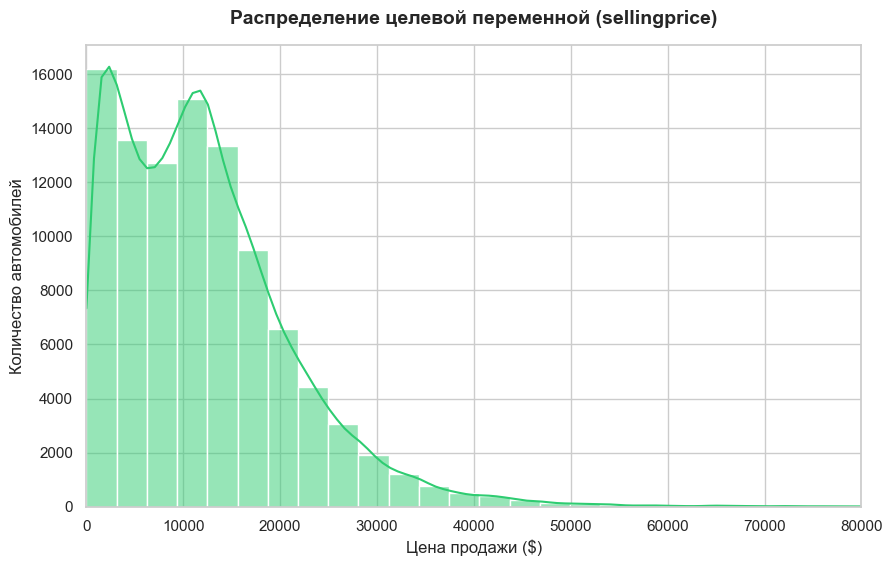

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Путь к данным (берем raw датасет, если его нет — sample)
data_path = 'data/raw/car_prices.csv'
if not os.path.exists(data_path):
    data_path = 'data/sample_car_prices.csv'

# Настраиваем стиль графика
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Строим гистограмму распределения цен (ограничим x-ось до $80 000 для наглядности, так как есть редкие суперкары)
sns.histplot(df['sellingprice'], bins=50, kde=True, color='#2ecc71')

# Добавляем подписи на русском языке
plt.title('Распределение целевой переменной (sellingprice)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Цена продажи ($)', fontsize=12)
plt.ylabel('Количество автомобилей', fontsize=12)
plt.xlim(0, 80000)  # Срезаем редкие выбросы, чтобы график был читаемым
plt.show()